In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
train_data = pd.read_csv('/Users/iqrashahzad/Documents/Ann Project/train.csv')
test_data = pd.read_csv('/Users/iqrashahzad/Documents/Ann Project/test.csv')

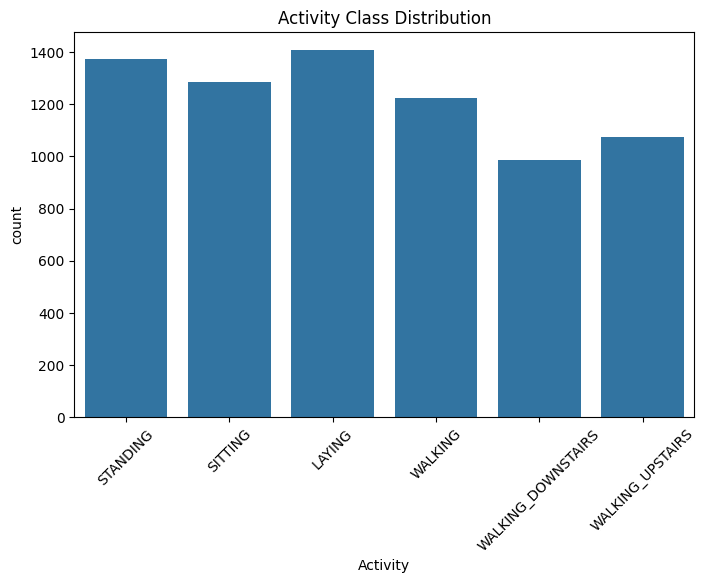

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x=train_data['Activity'])
plt.xticks(rotation=45)
plt.title("Activity Class Distribution")
plt.show()

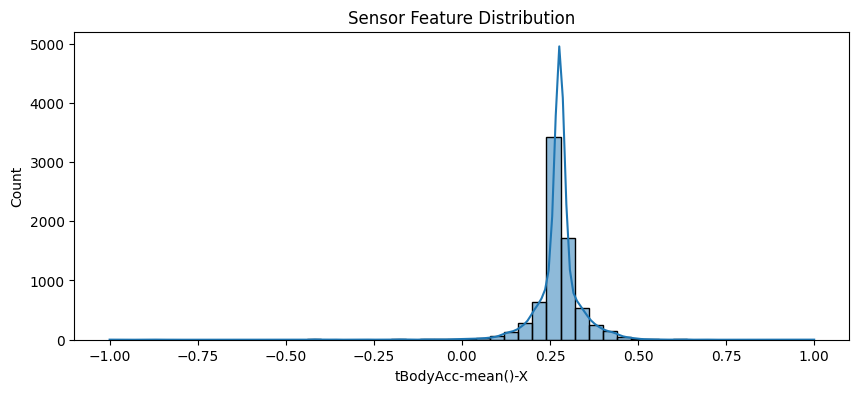

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(train_data.iloc[:,0], bins=50, kde=True)
plt.title("Sensor Feature Distribution")
plt.show()

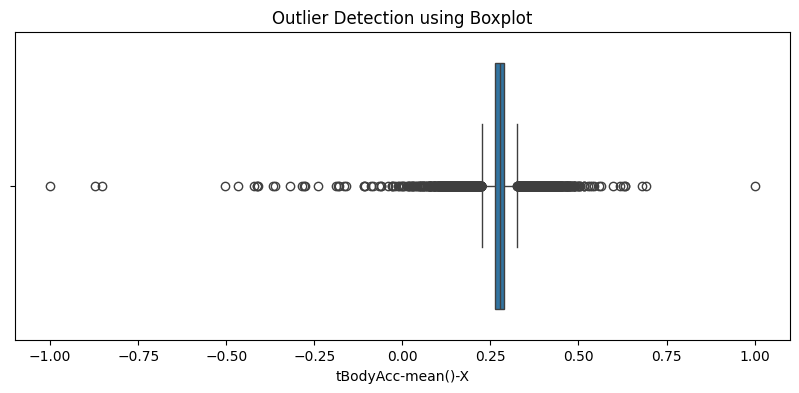

In [13]:
plt.figure(figsize=(10,4))
sns.boxplot(x=train_data.iloc[:,0])
plt.title("Outlier Detection using Boxplot")
plt.show()

In [14]:
X_train = train_data.drop('Activity', axis=1)
y_train = train_data['Activity']

X_test = test_data.drop('Activity', axis=1)
y_test = test_data['Activity']

In [15]:
def cap_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df.clip(lower, upper, axis=1)

X_train = cap_outliers(X_train)
X_test = cap_outliers(X_test)

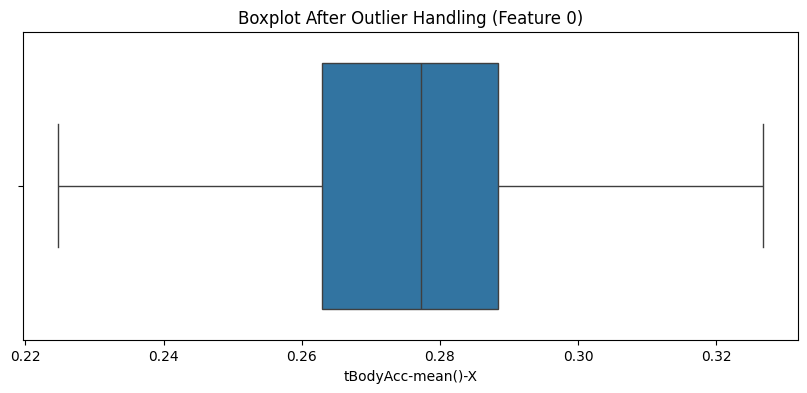

In [19]:
X_train_df = pd.DataFrame(X_train, columns=train_data.columns[:-1])  # use original feature names

plt.figure(figsize=(10,4))
sns.boxplot(x=X_train_df.iloc[:, 0])
plt.title("Boxplot After Outlier Handling (Feature 0)")
plt.show()

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

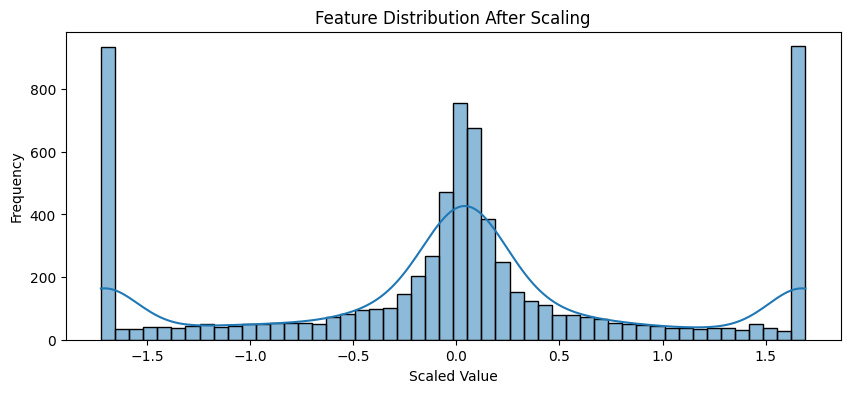

In [21]:
plt.figure(figsize=(10,4))
sns.histplot(X_train[:, 0], bins=50, kde=True)
plt.title("Feature Distribution After Scaling")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

In [22]:
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.values.reshape(-1,1))
y_test = encoder.transform(y_test.values.reshape(-1,1))


In [23]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

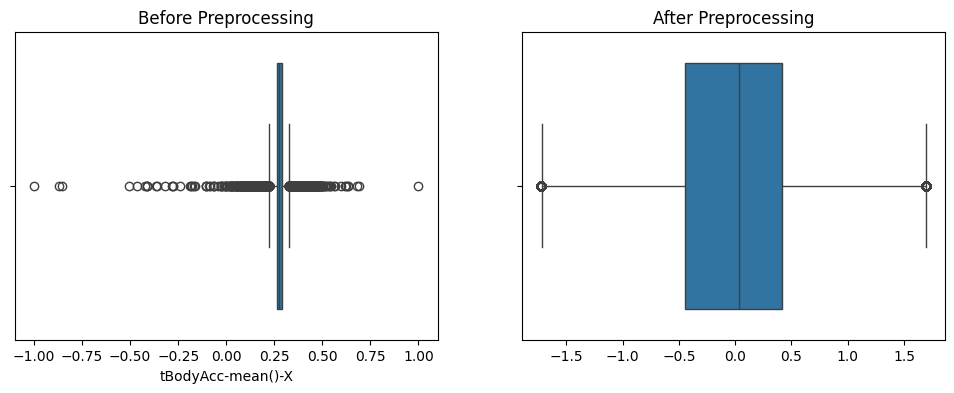

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x=train_data.iloc[:,0])
plt.title("Before Preprocessing")

plt.subplot(1,2,2)
sns.boxplot(x=X_train[:,0])
plt.title("After Preprocessing")

plt.show()

In [25]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(y_train_final.shape[1], activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        72,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,366 (325.65 KB)

 Trainable params: 82,982 (324.15 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7269 - loss: 0.7106 - val_accuracy: 0.9266 - val_loss: 0.2229
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8895 - loss: 0.3030 - val_accuracy: 0.9456 - val_loss: 0.1457
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9199 - loss: 0.2201 - val_accuracy: 0.9538 - val_loss: 0.1159
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9349 - loss: 0.1941 - val_accuracy: 0.9592 - val_loss: 0.1161
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9337 - loss: 0.1788 - val_accuracy: 0.9606 - val_loss: 0.0964
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9454 - loss: 0.1509 - val_accuracy: 0.9646 - val_loss: 0.0912
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9526 - loss: 0.1294 - val_accuracy: 0.9762 - val_loss: 0.0719
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9444 - loss: 0.1459 - val_accu

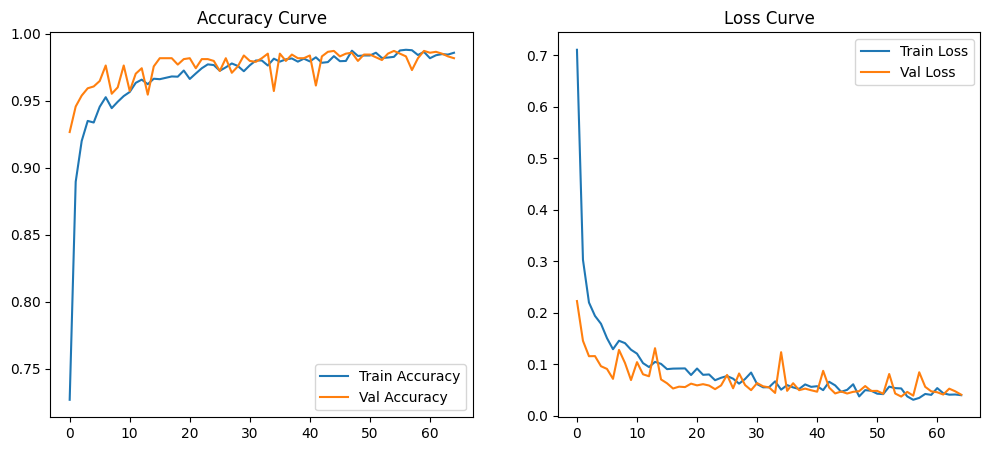

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

In [28]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.9379029521547336

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       537
           1       0.91      0.87      0.89       491
           2       0.88      0.97      0.92       532
           3       0.93      0.99      0.96       496
           4       0.95      0.96      0.95       420
           5       0.97      0.90      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



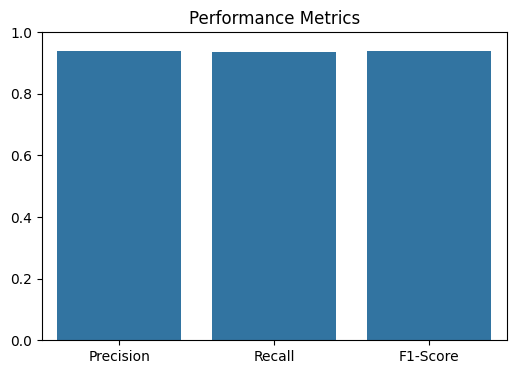

In [29]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)

metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]

plt.figure(figsize=(6,4))
sns.barplot(x=metrics, y=values)
plt.ylim(0,1)
plt.title("Performance Metrics")
plt.show()